## DBSCAN Algorthim

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
from scipy import stats


In [2]:
df = pd.read_csv('../Data/SampleDataCleaned.csv')

In [3]:
df.head()

,LocationID,Recency,Frequency,MonetaryValue,CLV,LocationName,BranchID,BranchName,InvoiceNumber,ProductGroup,...,SalesDate,ExtCost,ExtPrice,SalesQty,UnitCost,UnitPrice,GM%,Profit,Year,Month
0,1,0.0,0.0,0.0,0.0,Dallas,1,ACME Inc,1320612,Electrical,...,2021-08-11,1685.15,2286.99,10.0,168.5150,228.6989,26.32,601.84,2021,8
1,1,0.0,0.0,0.0,0.0,Dallas,1,ACME Inc,1320619,Electrical,...,2021-08-11,52.74,90.15,10.0,5.2743,9.0149,41.49,37.41,2021,8
2,1,0.0,0.0,0.0,0.0,Dallas,1,ACME Inc,1320621,Electrical,...,2021-08-11,41.31,59.02,1.0,41.3138,59.0197,30.00,17.71,2021,8
3,1,0.0,0.0,0.0,0.0,Dallas,1,ACME Inc,1320621,Electrical,...,2021-08-11,8.78,13.46,1.0,8.7770,13.4642,34.81,4.68,2021,8
4,1,0.0,0.0,0.0,0.0,Dallas,1,ACME Inc,1320622,Electrical,...,2021-08-11,49.97,64.62,2.0,24.9847,32.3090,22.67,14.65,2021,8


In [4]:
df.tail()

,LocationID,Recency,Frequency,MonetaryValue,CLV,LocationName,BranchID,BranchName,InvoiceNumber,ProductGroup,...,SalesDate,ExtCost,ExtPrice,SalesQty,UnitCost,UnitPrice,GM%,Profit,Year,Month
519555,2,0.0,0.0,0.0,0.0,Boston,2,Star Supply,6097117,Cutting Tools,...,2023-12-24,37.32,49.17,750.0,0.0498,0.0656,24.10,11.85,2023,12
519556,2,0.0,0.0,0.0,0.0,Boston,2,Star Supply,6097762,Cutting Tools,...,2023-12-27,37.32,49.17,750.0,0.0498,0.0656,24.10,11.85,2023,12
519557,2,0.0,0.0,0.0,0.0,Boston,2,Star Supply,6099503,Security,...,2023-12-30,684.98,1012.46,1000.0,0.6850,1.0125,32.34,327.48,2023,12
519558,2,0.0,0.0,0.0,0.0,Boston,2,Star Supply,6098337,Security,...,2023-12-28,684.98,1012.46,1000.0,0.6850,1.0125,32.34,327.48,2023,12
519559,2,0.0,0.0,0.0,0.0,Boston,2,Star Supply,6096458,Security,...,2023-12-23,684.98,1012.46,1000.0,0.6850,1.0125,32.34,327.48,2023,12


In [5]:
df.shape

(519560, 23)

In [6]:
df['SalesDate']=pd.to_datetime(df['SalesDate'])

In [7]:
df_2023 = df[(df['SalesDate'] >= '2023-01-01') & (df['SalesDate'] <= '2023-12-31')] 
df_2023['SalesDate'].sort_values()

231342   2023-01-01
483359   2023-01-01
101734   2023-01-01
99465    2023-01-01
231298   2023-01-01
            ...    
517269   2023-12-31
517767   2023-12-31
151133   2023-12-31
517762   2023-12-31
150609   2023-12-31
Name: SalesDate, Length: 158742, dtype: datetime64[ns]

In [8]:
df_2023 =df_2023.drop(columns=['LocationID','LocationName','BranchID','BranchName','InvoiceNumber'])

In [9]:
df_2023['ExtPrice'] = df_2023['ExtPrice'].replace('[\$,]', '', regex=True).astype(float)
df_2023['ExtCost'] = df_2023['ExtCost'].replace('[\$,]', '', regex=True).astype(float)
df_2023['UnitCost'] = df_2023['UnitCost'].replace('[\$,]', '', regex=True).astype(float)
df_2023['UnitPrice'] = df_2023['UnitPrice'].replace('[\$,]', '', regex=True).astype(float)

In [10]:
DBSCAN_df = df_2023.groupby('CustomerCode').agg({'SalesDate': lambda date: (df_2023['SalesDate'].max().date() - date.max().date()).days})

In [11]:
DBSCAN_df.rename(columns={'SalesDate': 'Recency'}, inplace=True)

In [12]:
DBSCAN_df['Frequency'] = df_2023['CustomerCode'].value_counts()

In [13]:
DBSCAN_df['Monetary'] = df_2023.groupby('CustomerCode')['ExtPrice'].sum()

In [14]:
DBSCAN_df.head()

,Recency,Frequency,Monetary
CustomerCode,,,
12346,91,3,7535.10
12348,8,58,555411.17
12350,11,39,5548.26
12352,1,30,3044.52
12354,115,115,621905.82


In [15]:
DBSCAN_df.head()

,Recency,Frequency,Monetary
CustomerCode,,,
12346,91,3,7535.10
12348,8,58,555411.17
12350,11,39,5548.26
12352,1,30,3044.52
12354,115,115,621905.82


In [30]:
'''D_df = pd.DataFrame()
D_df['Frequency'] = np.log(DBSCAN_df['Frequency'])
D_df['Recency'] = np.log(DBSCAN_df['Recency'])
D_df['Monetary'] = np.cbrt(DBSCAN_df['Monetary'])'''

"D_df = pd.DataFrame()\nD_df['Frequency'] = np.log(DBSCAN_df['Frequency'])\nD_df['Recency'] = np.log(DBSCAN_df['Recency'])\nD_df['Monetary'] = np.cbrt(DBSCAN_df['Monetary'])"

In [31]:
t = DBSCAN_df.iloc[:,0:].values


,0,1,2
0,91.0,3.0,7535.10
1,8.0,58.0,555411.17
2,11.0,39.0,5548.26
3,1.0,30.0,3044.52
4,115.0,115.0,621905.82


In [372]:
#DBSCAN_df

array([[ 4.51085951, 19.60482666],
       [ 2.07944154, 82.19994682],
       [ 2.39789527, 17.70322007],
       ...,
       [ 2.63905733, 19.36171285],
       [ 0.69314718, 23.35797239],
       [ 5.64897424,  7.34830047]])

In [35]:
def fix_skewness(df, columns):
    """
    Fix skewness in specified columns of a DataFrame using Box-Cox transformation.

    Parameters:
    - df: DataFrame: Input DataFrame
    - columns: list of str: List of column names to fix skewness

    Returns:
    - df_fixed: DataFrame: DataFrame with skewness fixed in specified columns
    """
    df_fixed = pd.DataFrame()
    for column in columns:
        df_fixed[column] = stats.boxcox(df[column])[0]
    return df_fixed

# Example usage:
db_df = pd.DataFrame()
db_df['Frequency'] = DBSCAN_df['Frequency']
db_df['Recency'] = DBSCAN_df['Recency']
db_df['Monetary'] = DBSCAN_df['Monetary']
db_df['Recency'] = db_df['Recency'].apply(lambda x: x+1)
columns = ['Recency', 'Frequency', 'Monetary']
customers_fix = fix_skewness(db_df, columns)
customers_fix.tail()

,Recency,Frequency,Monetary
1428,6.736033,2.454311,8.857332
1429,3.157350,3.557746,9.330432
1430,3.518716,2.486490,8.069662
1431,1.218661,2.876518,8.529136
1432,9.996351,1.019485,5.604002


In [36]:
def scaleData(data):
    scaler = StandardScaler()
    scaler.fit(data)
    scaler.transform(data)
    return scaler.transform(data)
customer_normalized = scaleData(db_df)
print(customer_normalized.mean(axis = 0).round(2))
print(customer_normalized.std(axis = 0).round(2))

[ 0. -0. -0.]
[1. 1. 1.]


c:\Users\Abdiwawi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\Abdiwawi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\Abdiwawi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
c:\Users\Abdiwawi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:767: Fu

In [37]:
#rfm_normalized = scaler.fit_transform(DBSCAN_df[:, [0, 1]])

In [68]:
model = DBSCAN(eps=0.09, min_samples=5).fit_predict(customer_normalized)
db_df['Cluster'] = model


In [69]:
db_df['Cluster'].value_counts()

Cluster
 0    1269
-1     147
 2      10
 1       7
Name: count, dtype: int64

In [48]:
# Create scatter plot
'''
plt.scatter(customer_normalized, rfm_normalized[:, 1], s=10, c="green")
plt.xlabel('Monetary')
plt.ylabel('Frequency')
plt.title('(Attempted) Normalized Scatter Plot')
plt.show()'''

'\nplt.scatter(customer_normalized, rfm_normalized[:, 1], s=10, c="green")\nplt.xlabel(\'Monetary\')\nplt.ylabel(\'Frequency\')\nplt.title(\'(Attempted) Normalized Scatter Plot\')\nplt.show()'

In [ ]:
DBSCAN_df

array([[ 1.09861229, 19.60482666],
       [ 4.06044301, 82.19994682],
       [ 3.66356165, 17.70322007],
       ...,
       [ 3.04452244, 19.36171285],
       [ 3.66356165, 23.35797239],
       [ 1.09861229,  7.34830047]])

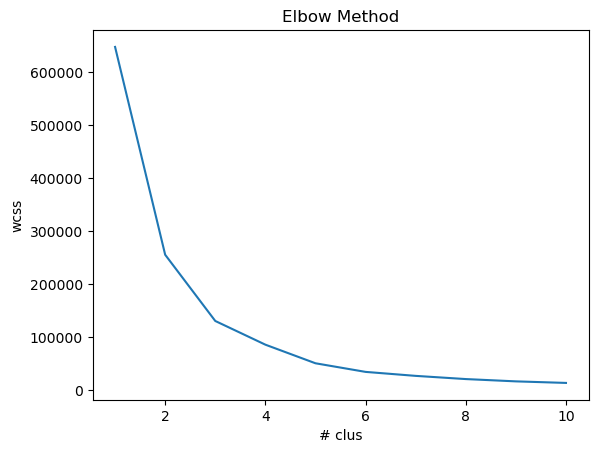

In [ ]:
wcss = []
for i in range(1,11):
    kmeans = KMeans (n_clusters= i,
    init = 'k-means++', max_iter = 300, n_init = 10)
    kmeans.fit(DBSCAN_df)
    wcss.append(kmeans.inertia_)
    

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("# clus")
plt.ylabel("wcss")
plt.show()

In [49]:
dbscan = DBSCAN(eps = 4, min_samples = 4)

In [50]:
labels = dbscan.fit_predict(DBSCAN_df)

c:\Users\Abdiwawi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
c:\Users\Abdiwawi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\Abdiwawi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


In [51]:
#Finds the noise of the df as -1

np.unique(labels)

array([-1], dtype=int64)

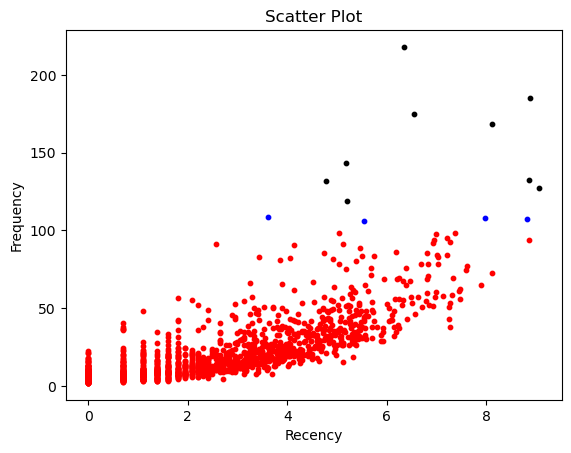

In [ ]:
plt.scatter(DBSCAN_df[labels == -1, 0], DBSCAN_df[labels == -1, 1], s=10, c='black')


plt.scatter(DBSCAN_df[labels == 0, 0], DBSCAN_df[labels == 0,1],s = 10, c = "red")
plt.scatter(DBSCAN_df[labels == 1, 0], DBSCAN_df[labels == 1,1],s = 10, c = "blue")
plt.scatter(DBSCAN_df[labels == 2, 0], DBSCAN_df[labels == 2,1],s = 10, c = "green")
plt.scatter(DBSCAN_df[labels == 3, 0], DBSCAN_df[labels == 3,1],s = 10, c = "orange")
plt.scatter(DBSCAN_df[labels == 4, 0], DBSCAN_df[labels == 4,0],s = 10, c = "purple")
plt.scatter(DBSCAN_df[labels == 5, 0], DBSCAN_df[labels == 5,0],s = 10, c = "pink")
plt.scatter(DBSCAN_df[labels == 6, 0], DBSCAN_df[labels == 6,0],s = 10, c = "brown")
plt.scatter(DBSCAN_df[labels == 7, 0], DBSCAN_df[labels == 7,0],s = 10, c = "cyan")
plt.scatter(DBSCAN_df[labels == 8, 0], DBSCAN_df[labels == 8,0],s = 10, c = "magenta")
plt.scatter(DBSCAN_df[labels == 9, 0], DBSCAN_df[labels == 9,0],s = 10, c = "yellow")
plt.scatter(DBSCAN_df[labels == 10, 0], DBSCAN_df[labels == 10,0],s = 10, c = "gray")
plt.scatter(DBSCAN_df[labels == 11, 0], DBSCAN_df[labels == 11,0],s = 10, c = "olive")
plt.scatter(DBSCAN_df[labels == 12, 0], DBSCAN_df[labels == 12,0],s = 10, c = "teal")
plt.scatter(DBSCAN_df[labels == 13, 0], DBSCAN_df[labels == 13,0],s = 10, c = "navy")
plt.scatter(DBSCAN_df[labels == 14, 0], DBSCAN_df[labels == 14,0],s = 10, c = "maroon")
plt.scatter(DBSCAN_df[labels == 15, 0], DBSCAN_df[labels == 15,0],s = 10, c = "lime")
plt.scatter(DBSCAN_df[labels == 16, 0], DBSCAN_df[labels == 16,0],s = 10, c = "indigo")
plt.scatter(DBSCAN_df[labels == 17, 0], DBSCAN_df[labels == 17,0],s = 10, c = "brown")

plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.title('Scatter Plot')
plt.show()
